In [79]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [80]:
data_df = pd.read_csv(r'./processed_household_power_consumption.csv', sep=',')
data_df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_energy_wh,Global_active_power_lag1,Global_active_power_lag24,...,Global_intensity_lag1,Global_intensity_rolling_mean24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,Global_active_power_rolling_std24,is_weekend_True
0,2.007133,0.126100,243.880667,8.313333,6.866667,0.866667,9.650000,16.068889,3.096833,4.349100,...,12.823333,12.269167,-0.866025,-5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.282565,True
1,1.686500,0.097833,238.020333,7.130000,0.000000,0.516667,0.000000,27.591667,2.007133,5.452533,...,8.313333,11.592917,-0.965926,-2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.178259,True
2,0.505200,0.119400,241.156333,2.110000,0.000000,0.600000,0.000000,7.820000,1.686500,3.879400,...,7.130000,10.999028,-1.000000,-1.836970e-16,-0.781831,0.623490,-2.449294e-16,1.000000,1.232380,True
3,0.454033,0.057233,241.419833,1.850000,0.000000,0.000000,0.000000,7.567222,0.505200,4.117833,...,2.110000,10.355278,-0.965926,2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.258524,True
4,0.474100,0.075367,241.942333,1.956667,0.000000,0.000000,0.000000,7.901667,0.454033,4.181400,...,1.850000,9.703611,-0.866025,5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.259679,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34393,1.725900,0.061400,237.069667,7.216667,0.000000,0.000000,12.866667,15.898333,1.067933,1.480100,...,4.610000,5.257500,-0.965926,-2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.726796,False
34394,1.573467,0.053700,237.531833,6.620000,0.000000,0.000000,0.000000,26.224444,1.725900,2.211600,...,7.216667,5.144028,-1.000000,-1.836970e-16,-0.433884,-0.900969,-5.000000e-01,0.866025,0.701471,False
34395,1.659333,0.060033,236.741000,7.056667,0.000000,0.066667,0.000000,27.588889,1.573467,2.330467,...,6.620000,5.029722,-0.965926,2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.668173,False
34396,1.163700,0.061167,239.396000,4.913333,0.000000,1.066667,0.000000,18.328333,1.659333,1.647833,...,7.056667,4.950000,-0.866025,5.000000e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.661320,False


In [81]:
X = data_df.drop(columns=['is_weekend_True'], errors='ignore')
display(X)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_energy_wh,Global_active_power_lag1,Global_active_power_lag24,...,Voltage_lag1,Global_intensity_lag1,Global_intensity_rolling_mean24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,Global_active_power_rolling_std24
0,2.007133,0.126100,243.880667,8.313333,6.866667,0.866667,9.650000,16.068889,3.096833,4.349100,...,243.182833,12.823333,12.269167,-0.866025,-5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.282565
1,1.686500,0.097833,238.020333,7.130000,0.000000,0.516667,0.000000,27.591667,2.007133,5.452533,...,243.880667,8.313333,11.592917,-0.965926,-2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.178259
2,0.505200,0.119400,241.156333,2.110000,0.000000,0.600000,0.000000,7.820000,1.686500,3.879400,...,238.020333,7.130000,10.999028,-1.000000,-1.836970e-16,-0.781831,0.623490,-2.449294e-16,1.000000,1.232380
3,0.454033,0.057233,241.419833,1.850000,0.000000,0.000000,0.000000,7.567222,0.505200,4.117833,...,241.156333,2.110000,10.355278,-0.965926,2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.258524
4,0.474100,0.075367,241.942333,1.956667,0.000000,0.000000,0.000000,7.901667,0.454033,4.181400,...,241.419833,1.850000,9.703611,-0.866025,5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.259679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34393,1.725900,0.061400,237.069667,7.216667,0.000000,0.000000,12.866667,15.898333,1.067933,1.480100,...,240.457833,4.610000,5.257500,-0.965926,-2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.726796
34394,1.573467,0.053700,237.531833,6.620000,0.000000,0.000000,0.000000,26.224444,1.725900,2.211600,...,237.069667,7.216667,5.144028,-1.000000,-1.836970e-16,-0.433884,-0.900969,-5.000000e-01,0.866025,0.701471
34395,1.659333,0.060033,236.741000,7.056667,0.000000,0.066667,0.000000,27.588889,1.573467,2.330467,...,237.531833,6.620000,5.029722,-0.965926,2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.668173
34396,1.163700,0.061167,239.396000,4.913333,0.000000,1.066667,0.000000,18.328333,1.659333,1.647833,...,236.741000,7.056667,4.950000,-0.866025,5.000000e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.661320


In [82]:
pipe = Pipeline([
    ('scaler', StandardScaler())
])

scaled_features = pipe.fit_transform(X)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)
display(scaled_df)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_energy_wh,Global_active_power_lag1,Global_active_power_lag24,...,Voltage_lag1,Global_intensity_lag1,Global_intensity_rolling_mean24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,Global_active_power_rolling_std24
0,1.041351,0.040270,1.020292,1.002007,1.635990,-0.098700,0.446574,0.839086,2.266365,3.665585,...,0.786016,2.213315,4.464823,-1.224458,-0.707174,-1.107575,0.881558,0.004849,1.454923,1.824467
1,0.680832,-0.385088,-0.946803,0.684125,-0.314699,-0.182932,-0.870997,2.257559,1.041203,4.903696,...,1.020251,1.001866,4.071895,-1.365731,-0.366074,-1.107575,0.881558,0.004849,1.454923,1.468362
2,-0.647416,-0.060552,0.105835,-0.664412,-0.314699,-0.162877,-0.870997,-0.176367,0.680711,3.138557,...,-0.946831,0.684006,3.726823,-1.413916,-0.000029,-1.107575,0.881558,0.004849,1.454923,1.653135
3,-0.704947,-0.996039,0.194282,-0.734257,-0.314699,-0.307275,-0.870997,-0.207484,-0.647438,3.406092,...,0.105800,-0.664436,3.352779,-1.365731,0.366016,-1.107575,0.881558,0.004849,1.454923,1.742390
4,-0.682384,-0.723168,0.369666,-0.705603,-0.314699,-0.307275,-0.870997,-0.166313,-0.704966,3.477417,...,0.194247,-0.734275,2.974136,-1.224458,0.707116,-1.107575,0.881558,0.004849,1.454923,1.746334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34393,0.725133,-0.933339,-1.265907,0.707406,-0.314699,-0.307275,0.885765,0.818090,-0.014751,0.446414,...,-0.128658,0.007099,0.390774,-1.365731,-0.366074,-0.615331,-1.273603,-0.697333,1.264018,-0.072945
34394,0.553738,-1.049209,-1.110774,0.547122,-0.314699,-0.307275,-0.870997,2.089252,0.725009,1.267196,...,-1.265932,0.707286,0.324843,-1.413916,-0.000029,-0.615331,-1.273603,-0.697333,1.264018,-0.159403
34395,0.650286,-0.953904,-1.376228,0.664425,-0.314699,-0.291231,-0.870997,2.257217,0.553626,1.400571,...,-1.110801,0.547013,0.258427,-1.365731,0.366016,-0.615331,-1.273603,-0.697333,1.264018,-0.273083
34396,0.092998,-0.936850,-0.485043,0.088655,-0.314699,-0.050567,-0.870997,1.117227,0.650167,0.634619,...,-1.376252,0.664308,0.212105,-1.224458,0.707116,-0.615331,-1.273603,-0.697333,1.264018,-0.296478


### Optimal Number of Clusters (K) using the Elbow Method

The elbow method helps to find an appropriate number of clusters for K-Means clustering. It plots the within-cluster sum of squares (WCSS) against the number of clusters. The 'elbow' point in the plot, where the rate of decrease in WCSS sharply changes, suggests an optimal K.


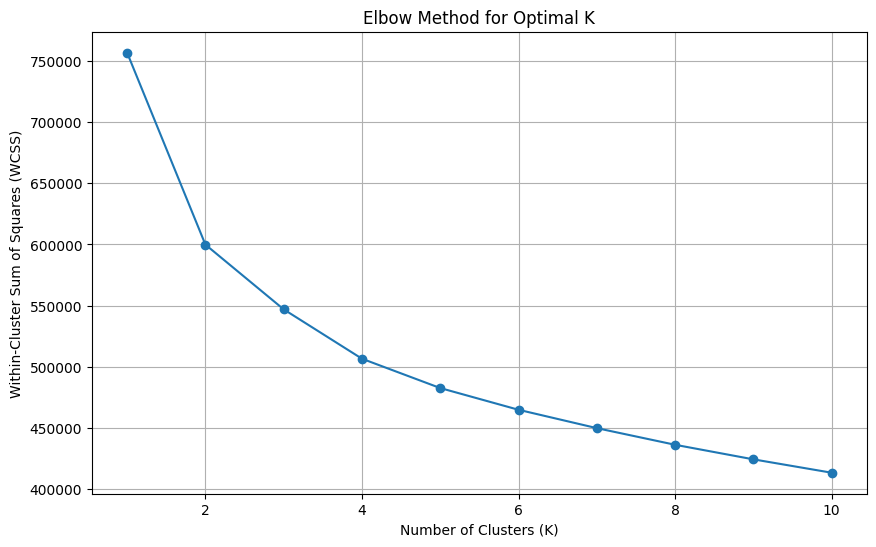

In [83]:
wcss = []
max_k = 10
for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

Based on the elbow method plot, our `n_clusters` is `K=3`


In [110]:
k_value = 3
kmeans = KMeans(
    n_clusters=k_value,
    init='k-means++',
    random_state=42,
    n_init='auto',
    verbose=0,
    max_iter=300
)

clusters = kmeans.fit_predict(scaled_df)
data_df['Cluster'] = clusters
display(data_df['Cluster'].value_counts())

,count
Cluster,
1,18731
0,11529
2,4138


In [111]:
labels = kmeans.labels_
labels

array([2, 2, 0, ..., 0, 0, 0], dtype=int32)

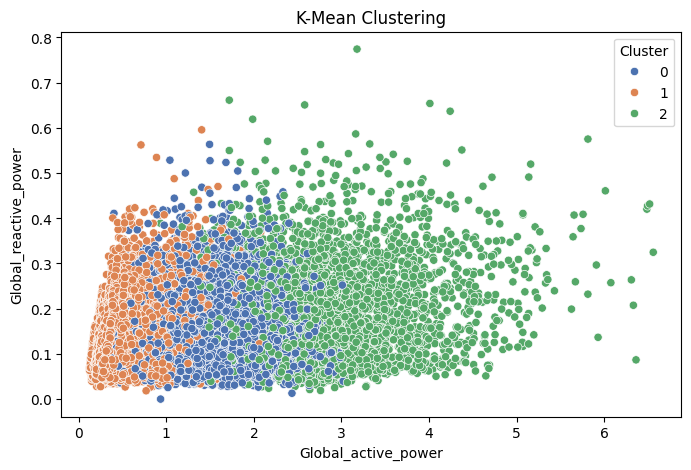

In [112]:
data_df['Cluster'] = labels
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data_df.Global_active_power, y=data_df.Global_reactive_power, hue=data_df.Cluster, palette='deep')
plt.title("K-Mean Clustering")
plt.xlabel("Global_active_power")
plt.ylabel("Global_reactive_power")
plt.show()

In [113]:
kmean_pred = kmeans.predict(scaled_df)
data_df['Cluster'] = kmean_pred
data_df['Cluster']

,Cluster
0,2
1,2
2,0
3,0
4,0
...,...
34393,0
34394,0
34395,0
34396,0


### Using `cluster_means` or `Centroid` to understand cluster characteristics

`cluster_means` or `Centroid` provides aggregated information about each cluster. We can use it to visualize and compare the average values of features across different clusters, helping us to interpret their meaning. Below, we plot the average `Global_active_power` for each cluster.

In [114]:
centroid = pipe.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroid, columns=X.columns)
display(centroid_df)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_energy_wh,Global_active_power_lag1,Global_active_power_lag24,...,Voltage_lag1,Global_intensity_lag1,Global_intensity_rolling_mean24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,Global_active_power_rolling_std24
0,1.457781,0.119439,240.271673,6.110228,1.139942,1.021134,11.746233,10.389038,1.478280,1.460077,...,240.263564,6.209453,5.211011,-0.014516,-0.314257,0.010753,-0.002689,0.112910,0.114354,0.837401
1,0.474808,0.113682,241.694533,2.066239,0.147095,0.449346,1.911844,5.405179,0.517694,0.680355,...,241.679083,2.238434,3.852479,0.120506,0.166184,0.031412,-0.016588,-0.112593,-0.190461,0.638666
2,2.777758,0.178677,238.560239,11.733762,5.371536,5.738908,11.664817,23.520707,2.526808,1.850350,...,238.653699,10.679075,6.159280,-0.506920,0.122991,-0.163424,0.081979,0.166796,0.369270,0.995620


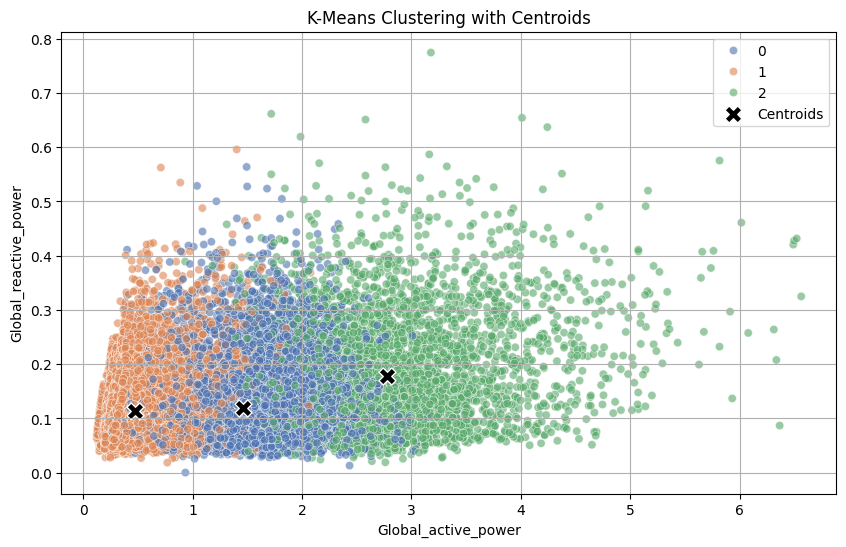

In [115]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_df['Global_active_power'], y=data_df['Global_reactive_power'], hue=data_df.Cluster, palette='deep',
                alpha=0.6)
sns.scatterplot(x=centroid_df['Global_active_power'], y=centroid_df['Global_reactive_power'], s=150, color='black', marker='X',
                label='Centroids', legend=False)
plt.title("K-Means Clustering with Centroids")
plt.xlabel("Global_active_power")
plt.ylabel("Global_reactive_power")
plt.legend()
plt.grid(True)
plt.show()

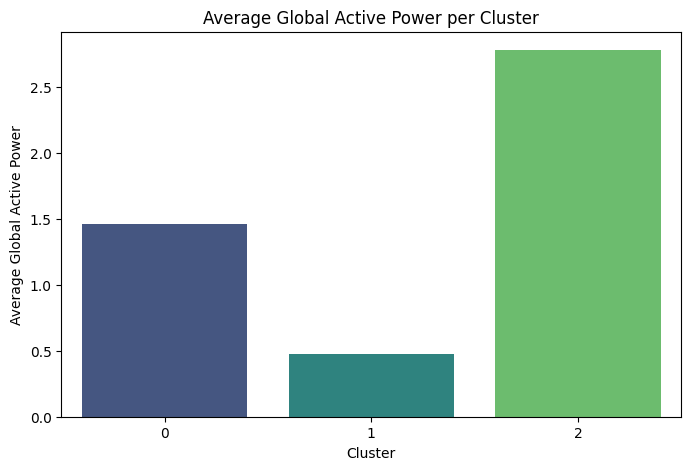

In [116]:
plt.figure(figsize=(8, 5))
sns.barplot(x=centroid_df.index, y=centroid_df['Global_active_power'], palette='viridis')
plt.title('Average Global Active Power per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Global Active Power')
plt.show()

In [117]:
save_model = joblib.dump(kmeans, "./kmean-cluster-model.pkl")